# Principal Component Analysis (PCA) — Case Study

## Customer Fidelity Prediction at UrbanMart

---

## 1. Business Context

**UrbanMart** is an online retail company specializing in household and lifestyle products. The marketing analytics team collected behavioral data on **n = 120 customers** with three goals:

1. **Dimensionality reduction:** reduce 8 correlated variables into a smaller set of interpretable dimensions. No consider Fidelity (the response variable in a future machile learning task)
2. **Visualization:** project customers onto the principal component space to discover segments.

---

## 2. Variable Description

The dataset contains 8 predictor variables organized in three behavioral domains, plus one response variable.

### Spending Behavior

| Variable | Type | Range | Description |
|----------|------|-------|-------------|
| `purchase_frequency` | Discrete | 1–20 | Number of purchases per month |
| `avg_order_value` | Continuous | 10–200 USD | Average dollar amount per order |
| `total_spent_year` | Continuous | 100–3,000 USD | Total expenditure in the past 12 months |

### Digital Engagement

| Variable | Type | Range | Description |
|----------|------|-------|-------------|
| `website_visits_month` | Discrete | 1–60 | Number of website visits per month |
| `email_open_rate` | Continuous | 5–85 % | Percentage of marketing emails opened |
| `app_sessions_week` | Discrete | 0–20 | Number of mobile app sessions per week |

### Customer Satisfaction

| Variable | Type | Range | Description |
|----------|------|-------|-------------|
| `support_satisfaction` | Ordinal | 1–10 | Self-reported satisfaction with customer support |
| `review_score` | Ordinal | 1.0–5.0 | Average product review score given by the customer |

### Response Variable

| Variable | Type | Range | Description |
|----------|------|-------|-------------|
| `fidelity_score` | Continuous | 0–100 | Composite loyalty index combining retention probability, repurchase intent, and Net Promoter Score |

---

## 3. Methodology

### 3.1 Standardization

Since PCA is sensitive to variable scales, all 8 predictors are standardized before analysis:

$$z_{ij} = \frac{x_{ij} - \bar{x}_j}{s_j}, \quad j = 1, \ldots, 8$$

### 3.2 Principal Component Analysis

PCA finds orthogonal linear combinations of the standardized variables that maximize variance. The $k$-th principal component is:

$$\text{PC}_k = a_{k1}\,z_1 + a_{k2}\,z_2 + \cdots + a_{k8}\,z_8$$

where $\mathbf{a}_k$ is the $k$-th eigenvector of the correlation matrix $\mathbf{R}$, and the eigenvalue $\lambda_k$ is the variance captured by $\text{PC}_k$. The proportion of total variance explained is:

$$\frac{\lambda_k}{\sum_{j=1}^{8} \lambda_j} = \frac{\lambda_k}{8}$$

### 3.3 From Loadings to Correlations

The raw loading $a_{kj}$ is the weight of variable $j$ in component $k$. To obtain the **correlation** between a variable and a component:

$$r(X_j,\, \text{PC}_k) = a_{kj} \times \sqrt{\lambda_k}$$

This rescales each loading by the standard deviation of its component, yielding a Pearson correlation on $[-1, +1]$.

---


In [7]:
import pandas as pd
data = pd.read_excel('OnlineCompany.xlsx')
data.head()

,purchase_frequency,avg_order_value,total_spent_year,website_visits_month,email_open_rate,app_sessions_week,support_satisfaction,review_score,fidelity_score
0,7,64,1044,22,47,7,4.2,2.9,58
1,6,47,689,4,24,3,5.6,3.3,42
2,7,60,1111,24,52,8,6.8,3.9,72
3,10,86,1491,5,16,1,8.8,4.4,64
4,5,47,731,20,44,6,3.8,2.6,45


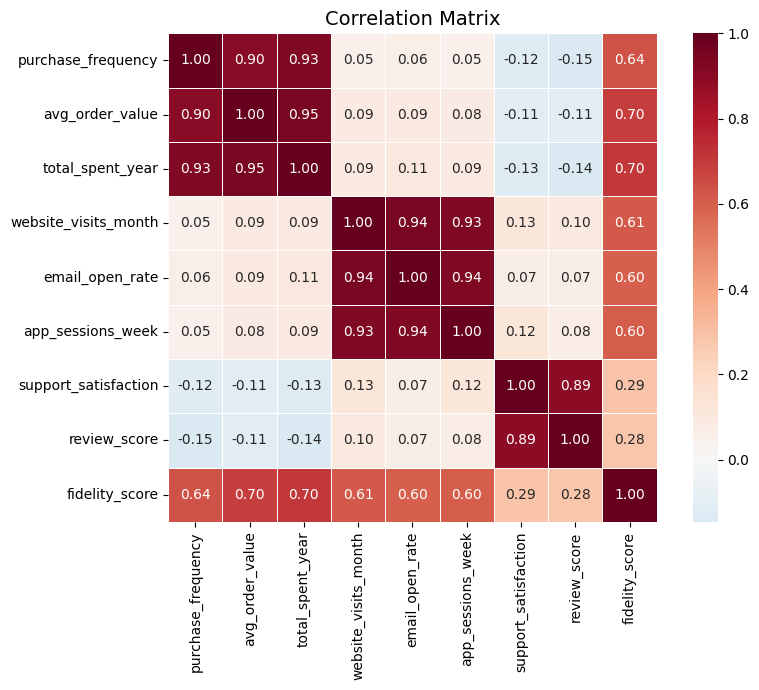

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(9, 7))
corr = data.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = data.drop(columns='fidelity_score')
y = data['fidelity_score']

# Always standardize before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit PCA — keep all components first to inspect variance
pca_full = PCA()
pca_full.fit(X_scaled)

variance_ratio = pd.DataFrame()
variance_ratio['Explained Variance Ratio'] = pca_full.explained_variance_ratio_
variance_ratio.head(9)

,Explained Variance Ratio
0,0.388164
1,0.348866
2,0.215936
3,0.015356
4,0.011530
5,0.008110
6,0.006262
7,0.005775


In [10]:
pca3 = PCA(n_components=3)
X_pca = pca3.fit_transform(X_scaled)

loadings = pd.DataFrame(
    pca3.components_.T,
    index=X.columns,
    columns=['PC1', 'PC2', 'PC3']
)

print(loadings.round(3))

                        PC1    PC2    PC3
purchase_frequency    0.403 -0.369  0.175
avg_order_value       0.418 -0.352  0.187
total_spent_year      0.426 -0.357  0.169
website_visits_month  0.398  0.397 -0.126
email_open_rate       0.404  0.384 -0.161
app_sessions_week     0.396  0.395 -0.140
support_satisfaction -0.032  0.278  0.649
review_score         -0.045  0.272  0.651


In [11]:
loadings = pca3.components_.T
eigenvalues = pca3.explained_variance_

# Multiply each loading column by sqrt of its eigenvalue
correlations = loadings * np.sqrt(eigenvalues)

df_corr = pd.DataFrame(
    correlations,
    index=X.columns,
    columns=['PC1', 'PC2', 'PC3']
)

print(df_corr.round(3))

                        PC1    PC2    PC3
purchase_frequency    0.713 -0.620  0.231
avg_order_value       0.740 -0.591  0.246
total_spent_year      0.754 -0.598  0.223
website_visits_month  0.704  0.667 -0.166
email_open_rate       0.715  0.644 -0.212
app_sessions_week     0.700  0.662 -0.185
support_satisfaction -0.057  0.466  0.856
review_score         -0.080  0.456  0.860


**PC1 — General Customer Activity**
All six spending and engagement variables load positively and almost equally (0.70–0.75) on PC1. The satisfaction variables are near zero. This component doesn't separate spenders from browsers — it captures overall activity level. A high PC1 customer buys a lot and visits a lot and opens emails. A low PC1 customer is inactive across the board. Think of it as "how much this person interacts with UrbanMart, period."


**PC2 — Spending vs. Digital Engagement (Channel Preference)**
The spending variables are strongly negative (−0.60) while the engagement variables are strongly positive (+0.65). Satisfaction is mildly positive. This component is a contrast: it separates customers who engage digitally (browse, open emails, use the app) but don't spend much, from customers who spend heavily but aren't digitally active. High PC2 = "window shopper" or digital-first browser. Low PC2 = "quiet big spender" who buys without much online interaction. This is a behavioral style dimension — how customers engage, not how much.


**PC3 — Customer Satisfaction**
Only support_satisfaction and review_score load heavily here (~0.86). Everything else is near zero. This is the cleanest component — pure satisfaction independent of spending or engagement. A customer can be highly satisfied regardless of whether they spend a lot or browse frequently.

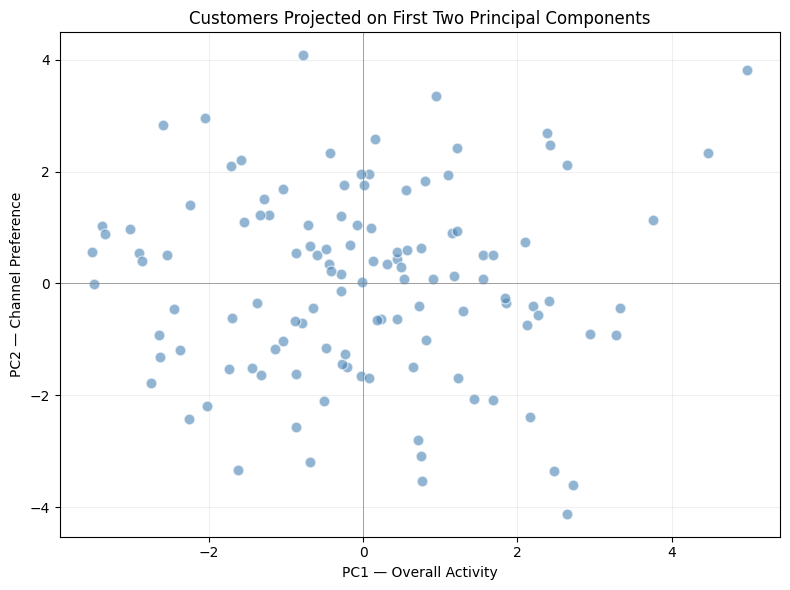

In [12]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c='steelblue', alpha=0.6, edgecolors='white', s=60)
plt.xlabel('PC1 — Overall Activity')
plt.ylabel('PC2 — Channel Preference')
plt.title('Customers Projected on First Two Principal Components')
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [13]:
projections = pd.DataFrame(
    X_pca,
    columns=['PC1_Activity', 'PC2_Channel', 'PC3_Satisfaction']
)

# Attach the original customer index
projections.index = data.index
projections.index.name = 'customer'
projections['Fidelity score'] = data.fidelity_score
projections.head(10)

,PC1_Activity,PC2_Channel,PC3_Satisfaction,Fidelity score
customer,,,,
0,1.851816,-0.352184,-1.108948,58
1,-1.148230,-1.178907,0.015317,42
2,2.102754,0.742472,0.478882,72
3,0.706388,-2.809606,3.216617,64
4,0.525389,0.082931,-1.830368,45
5,2.390357,2.693163,-1.549369,55
6,0.764963,-3.540153,0.750282,54
7,0.641721,-1.500235,-0.555513,50
8,-0.715080,1.042424,1.854678,51


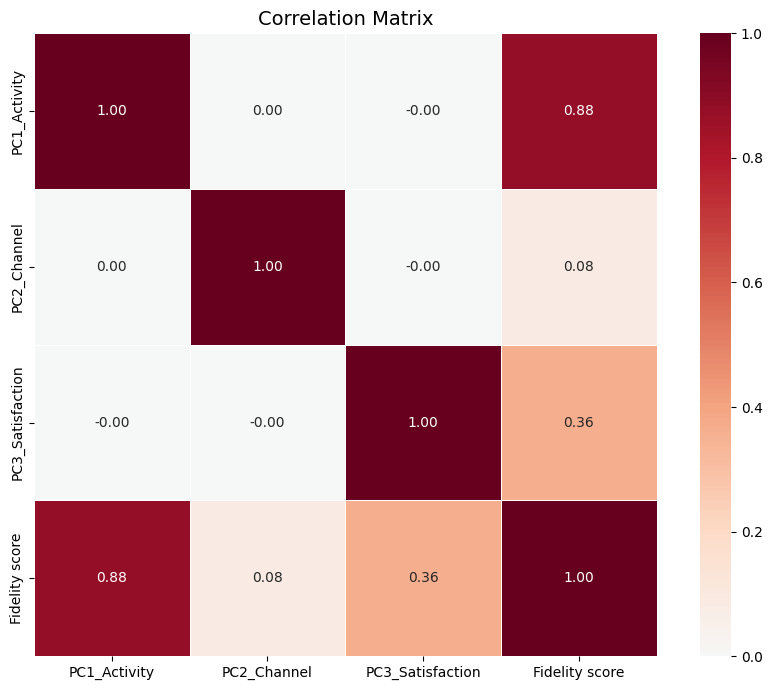

In [14]:
plt.figure(figsize=(9, 7))
corr = projections.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()